# Analysis of the Chess Database
Author: Giorgio Gobbin (Matricola: 683071) Course: Distributed Data Analysis and Mining

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col


spark = SparkSession.builder \
    .appName("ChessAnalysis") \
    .getOrCreate()

df = spark.read.csv('chess.csv', header=True, inferSchema=True)


df_final = df.withColumn("EloDiff", col("WhiteElo") - col("BlackElo")) \
             .withColumnRenamed("Risultato", "Label") 


4. Supervised Learning: Predicting the Winner


--- SUPERVISED LEARNING SETUP ---
Training Random Forest...


26/01/28 22:31:36 WARN MemoryStore: Not enough space to cache rdd_105_11 in memory! (computed 17.8 MiB so far)
26/01/28 22:31:36 WARN BlockManager: Persisting block rdd_105_11 to disk instead.
26/01/28 22:31:36 WARN MemoryStore: Not enough space to cache rdd_105_8 in memory! (computed 17.8 MiB so far)
26/01/28 22:31:36 WARN BlockManager: Persisting block rdd_105_8 to disk instead.
26/01/28 22:31:36 WARN MemoryStore: Not enough space to cache rdd_105_10 in memory! (computed 27.4 MiB so far)
26/01/28 22:31:36 WARN BlockManager: Persisting block rdd_105_10 to disk instead.
26/01/28 22:31:36 WARN MemoryStore: Not enough space to cache rdd_105_9 in memory! (computed 27.4 MiB so far)
26/01/28 22:31:36 WARN BlockManager: Persisting block rdd_105_9 to disk instead.
26/01/28 22:31:44 WARN MemoryStore: Not enough space to cache rdd_105_13 in memory! (computed 11.5 MiB so far)
26/01/28 22:31:44 WARN BlockManager: Persisting block rdd_105_13 to disk instead.
26/01/28 22:31:44 WARN MemoryStore: Not

Random Forest Accuracy: 0.6305

Feature Importance:
      Feature  Importance
2     EloDiff    0.764108
0    WhiteElo    0.119080
1    BlackElo    0.107902
3  GameLength    0.008909


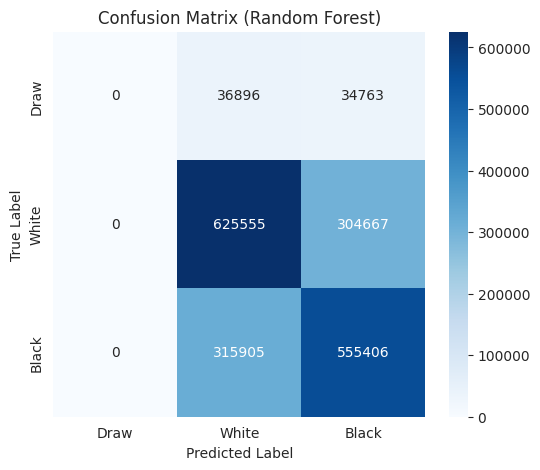

In [ ]:
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import RandomForestClassifier, DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator


# 1. Preparazione Feature
feature_cols = ["WhiteElo", "BlackElo", "EloDiff", "GameLength"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

data_ml = assembler.transform(df_final).select("features", "Label", "ECO")

# 2. Train/Test Split
train_data, test_data = data_ml.randomSplit([0.7, 0.3], seed=42)

# 3. Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(labelCol="Label", featuresCol="features", numTrees=20, maxBins=1000)
rf_model = rf.fit(train_data)
rf_preds = rf_model.transform(test_data)

# 4. Evaluation
evaluator = MulticlassClassificationEvaluator(labelCol="Label", predictionCol="prediction", metricName="accuracy")
rf_acc = evaluator.evaluate(rf_preds)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

# 5. Feature Importance
import pandas as pd
feat_imp = pd.DataFrame(list(zip(feature_cols, rf_model.featureImportances.toArray())), columns=['Feature', 'Importance'])
print("\nFeature Importance:")
print(feat_imp.sort_values(by='Importance', ascending=False))

# --- PLOT CONFUSION MATRIX ---
from sklearn.metrics import confusion_matrix
y_true = rf_preds.select("Label").toPandas()
y_pred = rf_preds.select("prediction").toPandas()
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Draw', 'White', 'Black'], yticklabels=['Draw', 'White', 'Black'])
plt.title('Confusion Matrix (Random Forest)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

5. Unsupervised Learning: Player Segmentation

--- CLUSTERING PREPARATION ---


Training K-Means (k=4)...


26/01/28 22:37:07 WARN MemoryStore: Not enough space to cache rdd_178_27 in memory! (computed 5.6 MiB so far)
26/01/28 22:37:07 WARN BlockManager: Persisting block rdd_178_27 to disk instead.
26/01/28 22:37:08 WARN MemoryStore: Not enough space to cache rdd_178_25 in memory! (computed 8.4 MiB so far)
26/01/28 22:37:08 WARN BlockManager: Persisting block rdd_178_25 to disk instead.
26/01/28 22:37:08 WARN MemoryStore: Not enough space to cache rdd_178_26 in memory! (computed 8.4 MiB so far)
26/01/28 22:37:08 WARN BlockManager: Persisting block rdd_178_26 to disk instead.
26/01/28 22:37:13 WARN MemoryStore: Not enough space to cache rdd_178_25 in memory! (computed 8.4 MiB so far)
26/01/28 22:37:13 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_178_26 in memory.
26/01/28 22:37:13 WARN MemoryStore: Not enough space to cache rdd_178_26 in memory! (computed 384.0 B so far)
26/01/28 22:37:13 WARN MemoryStore: Not enough space to cache rdd_178

Analisi Cluster...


/tmp/ipykernel_55/4159755117.py:56: FutureWarning:                              

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster_Name', y='Avg_Elo', data=plot_data, ax=axes[0], palette='Blues_d'); axes[0].set_title('Skill Level')


   prediction      Avg_Elo   Avg_Length     Avg_Gap    Count Cluster_Name
0           0  1952.764835   472.746319   97.699141  2340142      Masters
1           1  1545.698622   408.150999  100.115170  2425912    Beginners
2           2  1745.373838  1898.264583  135.731116   567829   Mismatches
3           3  1715.641669   442.988608  406.537736   907671    Marathons


/tmp/ipykernel_55/4159755117.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster_Name', y='Avg_Length', data=plot_data, ax=axes[1], palette='Greens_d'); axes[1].set_title('Game Duration')
/tmp/ipykernel_55/4159755117.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster_Name', y='Avg_Gap', data=plot_data, ax=axes[2], palette='Reds_d'); axes[2].set_title('Elo Gap')


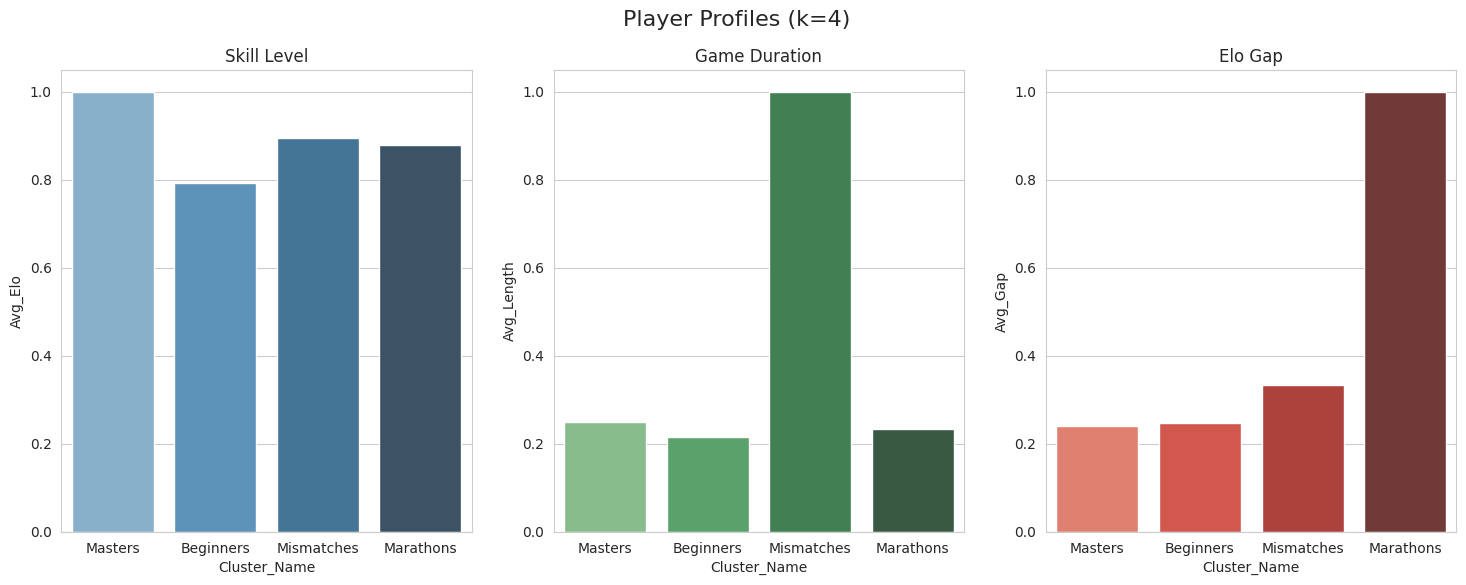

In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import StandardScaler

print("--- CLUSTERING PREPARATION ---")

# 1. Assembler e Scaling
cluster_cols = ["AverageElo", "GameLength", "EloGap"]
assembler_cl = VectorAssembler(inputCols=cluster_cols, outputCol="features_raw")
data_cl = assembler_cl.transform(df_final)

scaler = StandardScaler(inputCol="features_raw", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(data_cl)
data_scaled = scaler_model.transform(data_cl)


# 3. K-MEANS
print("Training K-Means (k=4)...")
kmeans = KMeans().setK(4).setSeed(1).setFeaturesCol("scaled_features")
model_k4 = kmeans.fit(data_scaled)
predictions_cl = model_k4.transform(data_scaled)

# 4. Interpretazione Cluster
print("Analisi Cluster...")
cluster_stats = predictions_cl.groupBy("prediction").agg(
    F.avg("AverageElo").alias("Avg_Elo"),
    F.avg("GameLength").alias("Avg_Length"),
    F.avg("EloGap").alias("Avg_Gap"),
    F.count("*").alias("Count")
).orderBy("prediction").toPandas()


name_mapping = {0: "Masters", 1: "Beginners", 2: "Marathons", 3: "Mismatches"}
cluster_stats['Cluster_Name'] = cluster_stats['prediction'].map(name_mapping)
print(cluster_stats)

# 5. Visualizzazione
plot_data = cluster_stats.copy()
for col in ["Avg_Elo", "Avg_Length", "Avg_Gap"]:
    plot_data[col] = plot_data[col] / plot_data[col].max() # Normalize for viz

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Player Profiles (k=4)', fontsize=16)
sns.barplot(x='Cluster_Name', y='Avg_Elo', data=plot_data, ax=axes[0], palette='Blues_d'); axes[0].set_title('Skill Level')
sns.barplot(x='Cluster_Name', y='Avg_Length', data=plot_data, ax=axes[1], palette='Greens_d'); axes[1].set_title('Game Duration')
sns.barplot(x='Cluster_Name', y='Avg_Gap', data=plot_data, ax=axes[2], palette='Reds_d'); axes[2].set_title('Elo Gap')
plt.show()

6. Pattern Mining & Regression

In [ ]:
from pyspark.ml.fpm import FPGrowth
from pyspark.ml.regression import LinearRegression

# --- PATTERN MINING ---
print("--- PATTERN MINING (FPGrowth) ---")
df_patterns = df_final.withColumn("items", F.array(F.col("Opening"), F.concat(F.lit("Result_"), F.col("Label"))))

fp = FPGrowth(itemsCol="items", minSupport=0.01, minConfidence=0.1)
fpm_model = fp.fit(df_patterns)

print("Top Association Rules found:")
fpm_model.associationRules.sort("confidence", ascending=False).show(5, truncate=False)

# --- REGRESSION ---
print("--- REGRESSION (EloDiff vs GameLength) ---")
assembler_reg = VectorAssembler(inputCols=["EloDiff"], outputCol="features_reg")
df_reg = assembler_reg.transform(df_final).select("features_reg", "GameLength")

lr = LinearRegression(featuresCol="features_reg", labelCol="GameLength")
lr_model = lr.fit(df_reg)

print(f"R2 Score: {lr_model.summary.r2:.5f}")
print(f"Coefficient: {lr_model.coefficients[0]:.4f}")
print("Result: No significant linear correlation found.")

--- PATTERN MINING (FPGrowth) ---


26/01/28 22:39:52 WARN MemoryStore: Not enough space to cache rdd_265_13 in memory! (computed 18.0 MiB so far)
26/01/28 22:39:52 WARN BlockManager: Persisting block rdd_265_13 to disk instead.
26/01/28 22:39:52 WARN MemoryStore: Not enough space to cache rdd_265_12 in memory! (computed 26.6 MiB so far)
26/01/28 22:39:52 WARN BlockManager: Persisting block rdd_265_12 to disk instead.
26/01/28 22:39:54 WARN MemoryStore: Not enough space to cache rdd_265_16 in memory! (computed 7.8 MiB so far)
26/01/28 22:39:54 WARN BlockManager: Persisting block rdd_265_16 to disk instead.
26/01/28 22:39:54 WARN MemoryStore: Not enough space to cache rdd_265_13 in memory! (computed 8.0 MiB so far)
26/01/28 22:39:54 WARN MemoryStore: Not enough space to cache rdd_265_19 in memory! (computed 3.5 MiB so far)
26/01/28 22:39:54 WARN BlockManager: Persisting block rdd_265_19 to disk instead.
26/01/28 22:39:55 WARN MemoryStore: Not enough space to cache rdd_265_17 in memory! (computed 11.8 MiB so far)
26/01/28 

Top Association Rules found:


+----------------------+----------+------------------+-----------------+--------------------+
|antecedent            |consequent|confidence        |lift             |support             |
+----------------------+----------+------------------+-----------------+--------------------+
|[Van't Kruijs Opening]|[Result_2]|0.5327603997981426|1.145695871846758|0.011332594414788368|
+----------------------+----------+------------------+-----------------+--------------------+

--- REGRESSION (EloDiff vs GameLength) ---


26/01/28 22:40:51 WARN Instrumentation: [2a20cab7] regParam is zero, which might cause numerical instability and overfitting.


R2 Score: 0.00023
Coefficient: -0.0379
Result: No significant linear correlation found.
